In [111]:
#import libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression


#load dataset
df = pd.read_csv('/Users/fabianatorres/Downloads/archive/Malware_and_benign_recognition.csv')
#display
df.head()

,File,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics,...,MinSectionEntropy,TextSectionSize,DataSectionSize,SuspiciousSectionNames,ImportedDLLs,ImportedFunctions,HasExportTable,ExportedFunctions,OverlaySize,Malicious
0,e_56_clip.exe,28672,24576,0,4864,4096,0,5368709120,7,49504,...,0.015920,24576,4096,0,7,85,0,0,0,0
1,8d9b19c7af036a2a3f6d710fdfb1f45ca1b476f2ad9484...,234496,72704,0,117581,4096,241664,268435456,4,320,...,3.054267,234496,7648,0,3,103,1,1,0,1
2,e0e908a62601140123531aca205c1d54e6a7ec851f09d4...,1024,1536,0,9134,8192,16384,268435456,3,34112,...,0.081539,1024,0,0,1,1,0,0,0,1
3,42438a67636a6981b4e3209449040f6b393f10fe0636df...,48640,75264,0,18028,4096,53248,4194304,5,32832,...,5.441382,48640,9440,0,3,13,0,0,0,1
4,d_233_CastLaunch.dll,73728,49152,0,9040,4096,0,6442450944,8,16736,...,0.015920,69632,4096,0,31,125,1,2,0,0


In [112]:
df.shape
#(rows, columns)

(1156, 27)

In [113]:
#inspect dataset
print("\n Dataset Info ")
print(df.info())


 Dataset Info 
<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   File                     1156 non-null   str    
 1   SizeOfCode               1156 non-null   int64  
 2   SizeOfInitializedData    1156 non-null   int64  
 3   SizeOfUninitializedData  1156 non-null   int64  
 4   AddressOfEntryPoint      1156 non-null   int64  
 5   BaseOfCode               1156 non-null   int64  
 6   BaseOfData               1156 non-null   int64  
 7   ImageBase                1156 non-null   uint64 
 8   NumberOfSections         1156 non-null   int64  
 9   DllCharacteristics       1156 non-null   int64  
 10  SizeOfImage              1156 non-null   int64  
 11  SizeOfHeaders            1156 non-null   int64  
 12  Characteristics          1156 non-null   int64  
 13  Subsystem                1156 non-null   int64  
 14  SectionCount       

In [114]:
#checking for null values
df.isna().sum()

File                       0
SizeOfCode                 0
SizeOfInitializedData      0
SizeOfUninitializedData    0
AddressOfEntryPoint        0
BaseOfCode                 0
BaseOfData                 0
ImageBase                  0
NumberOfSections           0
DllCharacteristics         0
SizeOfImage                0
SizeOfHeaders              0
Characteristics            0
Subsystem                  0
SectionCount               0
AvgSectionEntropy          0
MaxSectionEntropy          0
MinSectionEntropy          0
TextSectionSize            0
DataSectionSize            0
SuspiciousSectionNames     0
ImportedDLLs               0
ImportedFunctions          0
HasExportTable             0
ExportedFunctions          0
OverlaySize                0
Malicious                  0
dtype: int64

Text(0.5, 1.0, 'Benign vs Malicious')

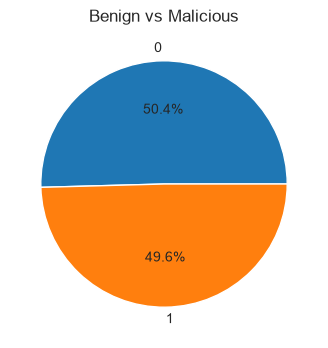

In [115]:
#visualizations
import seaborn as sns

sns.set_style('darkgrid') #color
plt.figure(figsize=(6,4)) #size
plt.pie(df['Malicious'].value_counts(), labels = df['Malicious'].value_counts().index, autopct='%1.1f%%')
plt.title('Benign vs Malicious')

In [116]:
x = df.drop(columns=["File", "Malicious"]) #this will hold all the the columns except Malicious and File
x

,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics,SizeOfImage,...,MaxSectionEntropy,MinSectionEntropy,TextSectionSize,DataSectionSize,SuspiciousSectionNames,ImportedDLLs,ImportedFunctions,HasExportTable,ExportedFunctions,OverlaySize
0,28672,24576,0,4864,4096,0,5368709120,7,49504,57344,...,5.532363,0.015920,24576,4096,0,7,85,0,0,0
1,234496,72704,0,117581,4096,241664,268435456,4,320,319488,...,6.493744,3.054267,234496,7648,0,3,103,1,1,0
2,1024,1536,0,9134,8192,16384,268435456,3,34112,32768,...,4.207035,0.081539,1024,0,0,1,1,0,0,0
3,48640,75264,0,18028,4096,53248,4194304,5,32832,135168,...,7.693362,5.441382,48640,9440,0,3,13,0,0,0
4,73728,49152,0,9040,4096,0,6442450944,8,16736,126976,...,5.945090,0.015920,69632,4096,0,31,125,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1151,339968,217088,0,9776,4096,0,5368709120,8,49504,561152,...,6.120012,0.015920,335872,39744,0,42,306,0,0,0
1152,4096,20480,0,4784,4096,0,6442450944,6,16736,28672,...,5.760829,0.055274,4096,4096,0,3,23,1,8,0
1153,24576,102400,0,5280,4096,0,5368709120,8,49504,131072,...,7.149948,0.013127,20480,4096,0,19,82,0,0,0
1154,401408,172032,0,63872,4096,0,6442450944,8,16736,577536,...,6.184443,0.015920,397312,12352,0,12,338,1,8,0


In [117]:
to_plot = [
    'SizeOfCode', 'SizeOfInitializedData', 
         'SizeOfUninitializedData', 'AddressOfEntryPoint', 
         'BaseOfData', 'ImageBase', 'NumberOfSections', 
         'DllCharacteristics'
]

x = df[to_plot]
y = df['Malicious']

In [118]:
x.shape

(1156, 8)

In [119]:
y.shape

(1156,)

In [120]:
#split the data
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 
#random_state=42  every time the code runs, the same split is generated
#test_size=0.2  20% of the split will be test and 80% will be train
x_train

,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics
58,56320,1536,0,64062,0,4194304,3,0
333,12288,28672,0,5056,0,6442450944,7,16736
332,591360,317440,0,49112,0,5368709120,5,33120
922,12288,106496,0,7840,0,5368709120,7,49504
63,89088,32256,0,90111,94208,268435456,5,0
...,...,...,...,...,...,...,...,...
1044,4096,5259264,0,4585,8192,268435456,5,0
1095,163840,155648,0,8240,0,5368709120,7,49504
1130,3773440,12288431,0,20930648,3780608,4194304,17,0
860,61440,36864,0,30176,0,6442450944,7,16736


In [121]:
#printing information aboout the length of splitted datasets
print(f"{len(x)} - number of elements in the entire dataset.")
print(f"{len(x_train)} - number of training elements.")
print(f"{len(x_test)} - number of testing elements.")
print(f"{len(x_train) + len(x_test)} - sum of training and testing elements.")

1156 - number of elements in the entire dataset.
924 - number of training elements.
232 - number of testing elements.
1156 - sum of training and testing elements.


In [122]:
x_train.describe()

,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics
count,9.240000e+02,9.240000e+02,9.240000e+02,9.240000e+02,9.240000e+02,9.240000e+02,924.000000,924.000000
mean,5.995398e+05,1.716365e+06,4.950165e+04,1.095373e+06,3.985754e+05,3.992831e+16,6.645022,21969.109307
std,2.085321e+06,8.604196e+06,6.742288e+05,7.040033e+06,1.606286e+06,8.577547e+17,2.344530,19320.855861
min,0.000000e+00,5.120000e+02,0.000000e+00,0.000000e+00,0.000000e+00,6.553600e+04,2.000000,0.000000
25%,1.932800e+04,3.686400e+04,0.000000e+00,4.940000e+03,0.000000e+00,2.684355e+08,5.000000,320.000000
50%,8.550400e+04,9.830400e+04,0.000000e+00,9.352000e+03,0.000000e+00,5.368709e+09,7.000000,16736.000000
75%,3.290880e+05,4.890880e+05,0.000000e+00,8.688800e+04,3.276800e+04,6.442451e+09,8.000000,34144.000000
max,3.564544e+07,2.161132e+08,1.363558e+07,1.184213e+08,1.379942e+07,1.844674e+19,21.000000,49632.000000


In [123]:
x_test.describe()

,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics
count,2.320000e+02,2.320000e+02,2.320000e+02,2.320000e+02,2.320000e+02,2.320000e+02,232.000000,232.000000
mean,5.427134e+05,1.342340e+06,6.109793e+04,7.098546e+05,3.997484e+05,1.590248e+17,6.844828,23599.310345
std,1.433476e+06,2.773701e+06,5.924947e+05,2.793902e+06,1.555079e+06,1.709025e+18,2.605700,19566.864800
min,0.000000e+00,1.536000e+03,0.000000e+00,0.000000e+00,0.000000e+00,6.553600e+04,2.000000,0.000000
25%,2.457600e+04,4.096000e+04,0.000000e+00,5.228000e+03,0.000000e+00,4.194304e+06,5.000000,320.000000
50%,9.523200e+04,1.187840e+05,0.000000e+00,1.361300e+04,0.000000e+00,5.368709e+09,7.000000,16736.000000
75%,3.829760e+05,5.885440e+05,0.000000e+00,2.178670e+05,5.324800e+04,5.368709e+09,8.000000,49472.000000
max,1.433139e+07,2.334669e+07,8.810496e+06,2.093065e+07,1.434419e+07,1.844674e+19,19.000000,49632.000000


In [124]:
df.describe()

,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics,SizeOfImage,...,MinSectionEntropy,TextSectionSize,DataSectionSize,SuspiciousSectionNames,ImportedDLLs,ImportedFunctions,HasExportTable,ExportedFunctions,OverlaySize,Malicious
count,1.156000e+03,1.156000e+03,1.156000e+03,1.156000e+03,1.156000e+03,1.156000e+03,1.156000e+03,1156.000000,1156.000000,1.156000e+03,...,1156.000000,1.156000e+03,1.156000e+03,1156.0,1156.000000,1156.000000,1156.000000,1156.000000,1.156000e+03,1156.000000
mean,5.881352e+05,1.641301e+06,5.182893e+04,1.018003e+06,5.199369e+04,3.988108e+05,6.383003e+16,6.685121,22296.277682,3.394535e+06,...,0.374243,7.565443e+05,1.026253e+06,0.0,14.129758,133.782872,0.525087,52.541522,1.240152e+06,0.495675
std,1.971440e+06,7.792484e+06,6.584114e+05,6.418082e+06,6.562292e+05,1.595476e+06,1.083692e+18,2.399384,19372.978532,1.232523e+07,...,1.047318,8.115890e+06,1.073135e+07,0.0,14.446993,154.320537,0.499586,421.767264,8.162107e+06,0.500198
min,0.000000e+00,5.120000e+02,0.000000e+00,0.000000e+00,4.096000e+03,0.000000e+00,6.553600e+04,2.000000,0.000000,1.228800e+04,...,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,2.048000e+04,3.686400e+04,0.000000e+00,4.944000e+03,4.096000e+03,0.000000e+00,2.684355e+08,5.000000,320.000000,1.146880e+05,...,0.000000,8.192000e+03,4.096000e+03,0.0,2.000000,15.000000,0.000000,0.000000,0.000000e+00,0.000000
50%,8.601600e+04,9.830400e+04,0.000000e+00,1.007200e+04,4.096000e+03,0.000000e+00,5.368709e+09,7.000000,16736.000000,3.706880e+05,...,0.015920,6.963200e+04,4.096000e+03,0.0,8.000000,105.000000,1.000000,1.000000,0.000000e+00,0.000000
75%,3.461120e+05,4.970240e+05,0.000000e+00,1.004785e+05,4.096000e+03,3.276800e+04,6.442451e+09,8.000000,34144.000000,3.386368e+06,...,0.020393,2.672640e+05,1.484800e+04,0.0,23.000000,171.000000,1.000000,3.000000,5.182500e+02,1.000000
max,3.564544e+07,2.161132e+08,1.363558e+07,1.184213e+08,1.363968e+07,1.434419e+07,1.844674e+19,21.000000,49632.000000,2.164695e+08,...,7.488385,2.684396e+08,2.685379e+08,0.0,81.000000,1945.000000,1.000000,8843.000000,1.012587e+08,1.000000


In [125]:
y_test

940     0
265     0
109     1
299     1
752     1
       ..
1133    0
514     0
380     0
952     1
1002    1
Name: Malicious, Length: 232, dtype: int64

In [126]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
x_train = scaler.fit_transform(x_train) #feature scaling on x training set
x_test = scaler.transform(x_test) #transforming the testing data based on the training data

In [145]:
#train and evaluate a binary classification model
from sklearn.metrics import classification_report, accuracy_score, precision_score, roc_auc_score

model = SVC(kernel='linear', C=1.0, random_state=42)

model.fit(x_train, y_train)

print(model.score(x_test,y_test))
#evalutes performance after the split / accuracy of the model's predictions


#predictions
y_preds=model.predict(x_test)
acc = accuracy_score(y_test, y_pred) #determines the correct overall amount of prediction
auc = roc_auc_score(y_test, y_pred)


# Report

print("             CLASSICAL RESULTS")
print(f"Accuracy: {acc:.2f}")

print("\nReport:")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malware (1)']))
#Accuracy: score that determines the correct overall amount of predictions
#Precision: how often the model was correct when predicting positive
#Recall: how often the model was able to correctly identify true positives out of all the positives

0.875
             CLASSICAL RESULTS
Accuracy: 0.88

Report:
              precision    recall  f1-score   support

  Benign (0)       0.81      0.96      0.88       109
 Malware (1)       0.96      0.80      0.87       123

    accuracy                           0.88       232
   macro avg       0.88      0.88      0.87       232
weighted avg       0.89      0.88      0.87       232



In [140]:
#Confusion Matrix
model = LogisticRegression().fit(x_train,y_train)
confusion_matrix = metrics.confusion_matrix(y_test,y_pred)
print(confusion_matrix)
# True Positives (correctly identified)  | False Negatives
# False Positives                        | True Negatives

[[105   4]
 [ 25  98]]


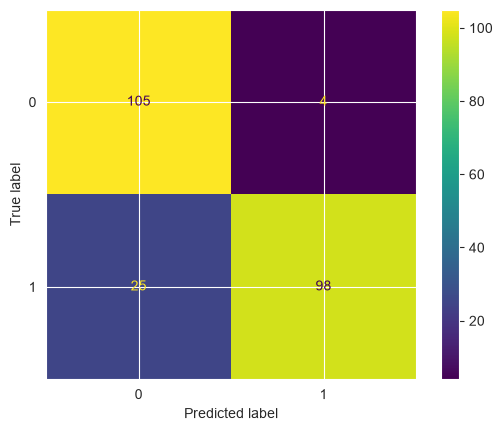

In [141]:
confusion_matrix_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix)
confusion_matrix_display.plot()
plt.show()